In [1]:
import pandas as pd
import numpy as np 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score)

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

sns.set_theme(style="whitegrid")
print("All libraries loaded!")

All libraries loaded!


In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df = df.drop(columns = ['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'])

X = df.drop(columns = ['Attrition'])
Y = df['Attrition'].map({'Yes':1,'No':0})

le = LabelEncoder()
text_columns = X.select_dtypes(include = 'str').columns.tolist()
for col in text_columns:
    X[col] = le.fit_transform(X[col])

scaler = StandardScaler()
numerical_columns = X.select_dtypes(include = ['int64','float64']).columns.tolist()
X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, random_state = 42, stratify = Y)

print("Data ready!")
print(f"Training: {X_train.shape}, Testing: {X_test.shape}")

Data ready!
Training: (1176, 30), Testing: (294, 30)


In [3]:
# Extreme Gradient Boosting                        

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=len(Y_train[Y_train==0]) / len(Y_train[Y_train==1]),
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

model.fit(X_train, Y_train)

print("Model trained successfully!")

Model trained successfully!


C:\Users\acer\Desktop\attrition-predictor\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:09:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [4]:
Y_pred = model.predict(X_test)
Y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"Sample predictions: {Y_pred[:10]}")
print(f"Sample probabilities: {Y_pred_proba[:10].round(2)}")

Sample predictions: [0 0 0 0 0 0 0 0 0 1]
Sample probabilities: [0.38 0.   0.02 0.   0.28 0.11 0.11 0.01 0.01 0.6 ]


In [5]:
print(classification_report(Y_test, Y_pred, 
                           target_names=['Stayed', 'Left']))

              precision    recall  f1-score   support

      Stayed       0.88      0.93      0.91       247
        Left       0.49      0.36      0.41        47

    accuracy                           0.84       294
   macro avg       0.68      0.64      0.66       294
weighted avg       0.82      0.84      0.83       294



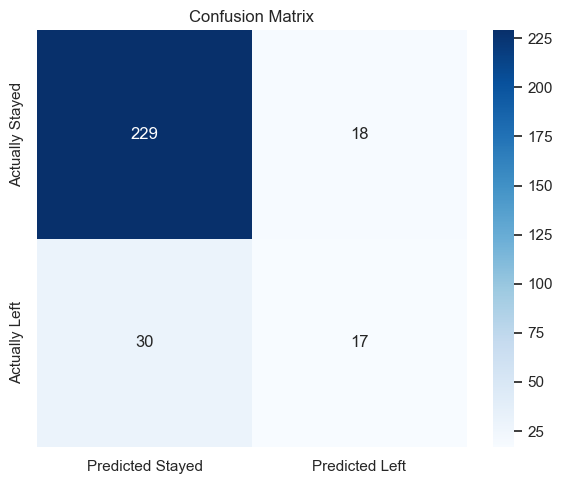

In [6]:
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed', 'Predicted Left'],
            yticklabels=['Actually Stayed', 'Actually Left'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [9]:
roc_auc = roc_auc_score(Y_test, Y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.3f}")

ROC-AUC Score: 0.780


In [12]:
# Try different thresholds and see the impact
thresholds = [0.5, 0.4, 0.3, 0.2]

for thresh in thresholds:
    Y_pred_thresh = (Y_pred_proba >= thresh).astype(int)
    cm = confusion_matrix(Y_test, Y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"Threshold {thresh} → Caught: {tp}/47 leavers | "
          f"False alarms: {fp} | "
          f"Recall: {recall:.0%} | "
          f"Precision: {precision:.0%}")

Threshold 0.5 → Caught: 17/47 leavers | False alarms: 18 | Recall: 36% | Precision: 49%
Threshold 0.4 → Caught: 21/47 leavers | False alarms: 26 | Recall: 45% | Precision: 45%
Threshold 0.3 → Caught: 25/47 leavers | False alarms: 34 | Recall: 53% | Precision: 42%
Threshold 0.2 → Caught: 31/47 leavers | False alarms: 51 | Recall: 66% | Precision: 38%


Final Model Performance at Threshold 0.3:
              precision    recall  f1-score   support

      Stayed       0.91      0.86      0.88       247
        Left       0.42      0.53      0.47        47

    accuracy                           0.81       294
   macro avg       0.67      0.70      0.68       294
weighted avg       0.83      0.81      0.82       294



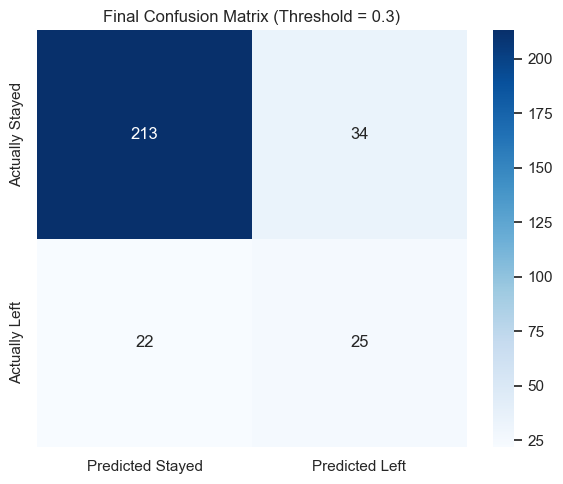

In [15]:
THRESHOLD = 0.3

Y_pred_final = (Y_pred_proba >= THRESHOLD).astype(int)

print("Final Model Performance at Threshold 0.3:")
print("="*50)
print(classification_report(Y_test, Y_pred_final,
                           target_names=['Stayed', 'Left']))

# Final confusion matrix
cm_final = confusion_matrix(Y_test, Y_pred_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed', 'Predicted Left'],
            yticklabels=['Actually Stayed', 'Actually Left'])
plt.title('Final Confusion Matrix (Threshold = 0.3)')
plt.tight_layout()
plt.show()

In [16]:
import pickle

# Save the model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the threshold
with open('threshold.pkl', 'wb') as f:
    pickle.dump(THRESHOLD, f)

# Save the feature names
feature_names = X.columns.tolist()
with open('features.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("Saved:")
print("  model.pkl     → trained XGBoost model")
print("  scaler.pkl    → fitted StandardScaler")
print("  threshold.pkl → our 0.3 threshold decision")
print("  features.pkl  → column names and order")

Saved:
  model.pkl     → trained XGBoost model
  scaler.pkl    → fitted StandardScaler
  threshold.pkl → our 0.3 threshold decision
  features.pkl  → column names and order
